In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
gt = pd.read_csv('ground_truth_labels.csv')

pred = pd.read_csv('predicted_results.csv')

In [ ]:
data =gt.merge(pred, on=['Sample_ID'])
data

,Sample_ID,Actual_Label,Predicted_Label,Predicted_Probability
0,1,0,0,0.257
1,2,1,1,0.855
2,3,1,1,0.726
3,4,1,1,0.803
4,5,0,0,0.243
...,...,...,...,...
95,96,1,1,0.740
96,97,1,1,0.890
97,98,0,0,0.086
98,99,0,0,0.249


In [ ]:
y_pred = data['Predicted_Label']
y_true = data['Actual_Label']
y_prob = data['Predicted_Probability']

In [ ]:
#Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
print(f"Accuracy Score: {accuracy_score(y_true, y_pred)}")
print(f'Precesion:{precision_score(y_true, y_pred)}')
print(f'Recall:{recall_score(y_true, y_pred)}')
print(f"F1 Score:{f1_score(y_true, y_pred)}")

Accuracy Score: 1.0
Precesion:1.0
Recall:1.0
F1 Score:1.0


In [ ]:
ConfusionMat = confusion_matrix(y_true, y_pred)
print(f"Confusion Matrix:\n{ConfusionMat}")

Confusion Matrix:
[[49  0]
 [ 0 51]]


In [ ]:
fpr,tpr,_ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
print(roc_auc)

1.0


In [ ]:
print(f"ROC AUC SCORE: {roc_auc_score(y_true, y_prob)}")

ROC AUC SCORE: 1.0


Text(0.5, 1.0, 'ROC Curve')

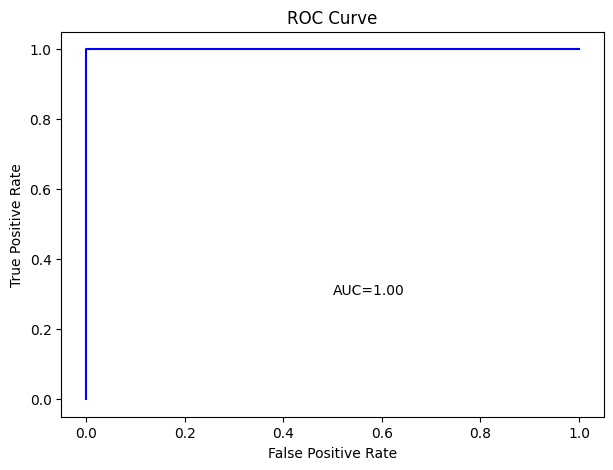

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC={roc_auc:.2f}')
plt.text(0.5,0.3,"AUC={:.2f}".format(roc_auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

#Task 2

In [ ]:
im_gt = pd.read_csv('imbalanced_ground_truth.csv')
im_pred = pd.read_csv('imbalanced_predictions.csv')

In [ ]:
im_data = im_gt.merge(im_pred, on=['Sample_ID'])

In [ ]:
y_pred1 = im_data['Predicted_Label']
y_true1 = im_data['Actual_Label']
y_prob1 = im_data['Predicted_Probability']

In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve
print(f"Accuracy:{accuracy_score(y_true1, y_pred1)}")
print(f'Classification Report:\n{classification_report(y_true1, y_pred1)}')

Accuracy:0.82
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89        90
           1       0.32      0.70      0.44        10

    accuracy                           0.82       100
   macro avg       0.64      0.77      0.67       100
weighted avg       0.90      0.82      0.85       100



Text(0, 0.5, 'Precision')

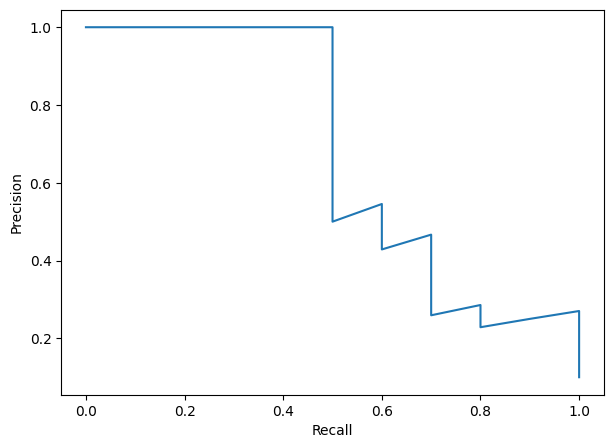

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_true1, y_prob1)
plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')